In [11]:
#Install packages
!pip install -q gensim hdbscan openTSNE gdown pyarrow umap-learn

In [12]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import drive
  drive.mount('/content/drive', force_remount=False)

  DRIVE_ROOT = '/content/drive/MyDrive'
else:
  DRIVE_ROOT = os.path.expanduser('~/Drive')

PROJECT_DIR = os.path.join(DRIVE_ROOT, 'CSDS 312 Project - Shared')
OUT_DIR = os.path.join(PROJECT_DIR, 'outputs', 'topic_modeling')
os.makedirs(OUT_DIR, exist_ok=True)
print('Outputs:', OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outputs: /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling


In [13]:
#Imports
import gzip, json, pickle, random, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim
from gensim.corpora import Dictionary, MmCorpus
from gensim.models import TfidfModel, LsiModel
from gensim.parsing.preprocessing import STOPWORDS as GENSIM_STOP
from gensim.utils import simple_preprocess

import hdbscan
from openTSNE import TSNE

RNG = np.random.default_rng(42)
random.seed(42)
print ('gensim', gensim.__version__)

gensim 4.4.0


In [14]:
#Configuration of processed Newsroom file
FILE_ID = '1ZlndsfaXTlzmmHNDtIYTQ2DZaUSCbwmJ'
LOCAL_GZ = '/content/newsroom_analysis_ready.csv.gz' if IN_COLAB else '/tmp/newsroom_analysis_ready.csv.gz'

#stratified smaple size
sample_n = 75_000

#pandas read_csv chunk size
chunk_size = 50_000

#full article
text_col = 'text'
pub_col = 'publisher_clean'
date_col = 'date'

#Preprocessing
min_token_len = 3
max_token_len = 25

#drop tokens appearing in fewer than N documents
no_below = 20
#drop tokens appearing in more than 50% of documents
no_above = 0.5
vocab_keep_n = 50_000

#LSI
lsi_topics = 200

#hdbscan
min_cluster_size = 250
#expecting a yield of 25-60 clusters given the size of 75k documents
min_samples = 10

#t-SNE
tsne_max_points = 30_000
#subsample for plot speed



In [15]:
import pandas as pd

# --- IMPORTANT: Updated path based on your request ---
# This assumes newsroom_analysis_ready.csv.gz is directly inside 'CSDS 312 Project - Shared'
newsroom_drive_path = os.path.join(PROJECT_DIR, 'newsroom_analysis_ready.csv.gz')

print(f"Attempting to load data from: {newsroom_drive_path}")

if os.path.exists(newsroom_drive_path):
    print(f'Loading data from Google Drive: {newsroom_drive_path}')
    try:
        # pandas can directly read gzipped files if the filename ends with .gz
        df_newsroom = pd.read_csv(newsroom_drive_path, compression='gzip', chunksize=chunk_size)
        # Read the first chunk to verify
        first_chunk = next(df_newsroom)
        print('Successfully loaded the first chunk of data from Google Drive.')
        display(first_chunk.head())

        # Re-initialize df_newsroom to iterate from the beginning
        df_newsroom = pd.read_csv(newsroom_drive_path, compression='gzip', chunksize=chunk_size)

    except Exception as e:
        print(f"Error loading file from Google Drive at {newsroom_drive_path}: {e}")
        print("Please ensure the file is not corrupted and accessible.")
else:
    print(f"File not found at {newsroom_drive_path}. ")
    print("Please ensure the path is correct and the file exists in your Google Drive.")
    print("You may need to manually verify the file's location in Google Drive and update 'newsroom_drive_path'.")

Attempting to load data from: /content/drive/MyDrive/CSDS 312 Project - Shared/newsroom_analysis_ready.csv.gz
Loading data from Google Drive: /content/drive/MyDrive/CSDS 312 Project - Shared/newsroom_analysis_ready.csv.gz
Successfully loaded the first chunk of data from Google Drive.


,title,summary,text,url,domain,publisher_clean,date,datetime,year,month,day,year_month_day,title_len,summary_len,text_len
0,Surge in Racist Mood Raises Concerns on Eve of...,A surge in discriminatory behavior toward blac...,"HAMBURG, Germany, June 3  As he left the socc...",http://www.nytimes.com/2006/06/04/sports/socce...,nytimes.com,nytimes,20060618204254,2006-06-18 20:42:54,2006,6,18,2006-06-18,56,105,12028
1,"Spy Agency Mined Vast Data Trove, Officials Re...","The volume of information harvested, without \...","WASHINGTON, Dec. 23 - The National Security Ag...",http://www.nytimes.com/2005/12/24/politics/24s...,nytimes.com,nytimes,20060620043011,2006-06-20 04:30:11,2006,6,20,2006-06-20,50,118,4282
2,Investors vs. Pfizer: Guess Who Has the Guns?,The battle between Pfizer Inc.'s investors and...,IF outsized executive pay has indeed become a ...,http://www.nytimes.com/2006/04/23/business/you...,nytimes.com,nytimes,20060909062911,2006-09-09 06:29:11,2006,9,9,2006-09-09,45,151,4654
3,REX FLEXED PECS FOR SKIN PICS,"If Simon Rex looks a little familiar, it may n...",BY A.J. BENZA & MICHAEL LEWITTES\n\nIf Simon R...,http://www.nydailynews.com/archives/gossip/199...,nydailynews.com,nydailynews,20080313232743,2008-03-13 23:27:43,2008,3,13,2008-03-13,29,370,4553
4,POPEYE-WORTHY PIE. PHYLLO DOUGH WRAPS SPINACH ...,POPEYE-WORTHY PIE. PHYLLO DOUGH WRAPS SPINACH ...,Spinach has terrorized generations of veggie-p...,http://www.nydailynews.com/archives/entertainm...,nydailynews.com,nydailynews,20080314003027,2008-03-14 00:30:27,2008,3,14,2008-03-14,58,454,1649


Insight into the Schema. Confirm column names before further analysis

In [16]:
peek = pd.read_csv(newsroom_drive_path, compression='gzip', nrows = 200, low_memory = False)
print('Columns:', list(peek.columns))
print('\nDtypes:')
print(peek.dtypes)
print('\nSample row:')
peek.head(1).T

Columns: ['title', 'summary', 'text', 'url', 'domain', 'publisher_clean', 'date', 'datetime', 'year', 'month', 'day', 'year_month_day', 'title_len', 'summary_len', 'text_len']

Dtypes:
title              object
summary            object
text               object
url                object
domain             object
publisher_clean    object
date                int64
datetime           object
year                int64
month               int64
day                 int64
year_month_day     object
title_len           int64
summary_len         int64
text_len            int64
dtype: object

Sample row:


,0
title,Surge in Racist Mood Raises Concerns on Eve of...
summary,A surge in discriminatory behavior toward blac...
text,"HAMBURG, Germany, June 3  As he left the socc..."
url,http://www.nytimes.com/2006/06/04/sports/socce...
domain,nytimes.com
publisher_clean,nytimes
date,20060618204254
datetime,2006-06-18 20:42:54
year,2006
month,6


In [17]:
#Clear stale cache
#import os
#if os.path.exists(sample_parquet):
#  os.remove(sample_parquet)
#  print('Removed stale cache:', sample_parquet)
#else:
#  print('No stale cache to remove:', sample_parquet)

In [18]:
sample_parquet = os.path.join(OUT_DIR, 'newsroom_sample.parquet')

# Corrected logic: if the file exists, load it; otherwise, process data to create it.
if os.path.exists(sample_parquet):
  sample = pd.read_parquet(sample_parquet)
  print('Loaded cache sample:', len(sample))
else:
  #Pass 1 - Count artiles per (publisher_clean, year) stratum
  t0 = time.time()
  counts=Counter()
  for chunk in pd.read_csv(newsroom_drive_path, compression='gzip', usecols = [pub_col, 'year'],
                           chunksize=chunk_size, low_memory=False):
    chunk = chunk.dropna(subset=['year'])
    chunk['year'] = chunk['year'].astype(int)
    for k, v in chunk.groupby([pub_col, 'year']).size().items():
      counts[k] += int(v)
  total = sum(counts.values())
  print(f'Pass 1 done in {time.time()-t0:}')
  # At this point, you would typically save the processed 'sample' DataFrame to sample_parquet
  # For example: sample.to_parquet(sample_parquet, index=False)

Pass 1 done in 50.957544565200806


In [19]:
if not os.path.exists(sample_parquet):
  #Proportional quotas with a floor of 3
  quotas = {k: max (3, int(round(sample_n * c / total))) for k, c in counts.items()}
  target = sum(quotas.values())
  print (f'Allocated {target:,} across {len(quotas)} strata')

  #Per-stratum acceptance rate
  #Possible oversample but will be trimmed later
  rates = {k: min(1.0, 1.15 * q / counts[k]) for k, q in quotas.items()}

  #Pass 2: strem plus per-row Bernoulli accept
  t0 = time.time()
  parts = []
  for chunk in pd.read_csv(newsroom_drive_path,
                           compression='gzip', chunksize=chunk_size,
                           low_memory=False):
      chunk = chunk.dropna(subset=['year'])
      chunk['year'] = chunk['year'].astype(int)
      r = np.array([rates.get((p,y),0.0)
                    for p, y in zip(chunk[pub_col], chunk['year'])])
      mask = RNG.random(len(chunk)) < r
      if mask.any():
        parts.append(chunk[mask].copy())

  pool = pd.concat(parts, ignore_index=True)
  print(f'Pass 2 done in {time.time()-t0:.1f}s. Pool before trim: {len(pool):,}')

  #Trim each stratum to exactly its quota
  def _trim(g):
    k = (g.iloc[0][pub_col], g.iloc[0]['year'])
    q = quotas.get(k,0)
    return g.sample(min(len(g), q), random_state=42) if q else g.iloc[0:0]
  sample = (pool.groupby([pub_col, 'year'], dropna=False, group_keys=False).apply(_trim).reset_index(drop=True))

  print('Final sample size:', len(sample))
  sample.to_parquet(sample_parquet, index=False)
  print('Saved ->', sample_parquet)

Allocated 75,100 across 294 strata
Pass 2 done in 75.5s. Pool before trim: 85,983


/tmp/ipykernel_84903/4031742928.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = (pool.groupby([pub_col, 'year'], dropna=False, group_keys=False).apply(_trim).reset_index(drop=True))


Final sample size: 75009
Saved -> /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/newsroom_sample.parquet


In [20]:
#Checking outlet and year coverage
print('Articles per outlet:')
display(sample[pub_col].value_counts().head(10))
print('\nArticles per year:')
display(sample['year'].value_counts().sort_index())

Articles per outlet:


,count
publisher_clean,
nytimes,11674
washingtonpost,7328
foxnews,6023
theguardian,4456
nydailynews,4260
wsj,3836
usatoday,3422
cnn,3297
time,3261



Articles per year:


,count
year,
2005,150
2006,595
2007,850
2008,1705
2009,2318
2010,4932
2011,6484
2012,8123
2013,7816


In [21]:
print('\nUnique years in sample:', sample['year'].unique())
print('\nFull articles per year breakdown:')
# Use to_string() to ensure no truncation when printing the Series
print(sample['year'].value_counts().sort_index().to_string())


Unique years in sample: [2014 2015 2016 2005 2006 2007 2008 2009 2010 2011 2012 2013]

Full articles per year breakdown:
year
2005      150
2006      595
2007      850
2008     1705
2009     2318
2010     4932
2011     6484
2012     8123
2013     7816
2014    10466
2015    14501
2016    17069


Preprocessing

In [22]:
extra_stop = {
    'said','say','says','saying','mr','ms','mrs','also','one','two','three',
    'would','could','should','may','might','must','get','got','like','many',
    'much','new','now','people','year','years','time','first','last','us','even',
    'back','going','know','see','still','make','made','take','really','way',
    'want','came','come','think','thought','told','told','according','reuters',
    'reuter','ap','cnn','nbc','abc','fox','wsj','nyt','yesterday','today','week',
    'month','monday','tuesday','wednesday','thursday','friday','saturday','sunday',
    'january','february','march','april','may','june','july','august','september',
    'october','november','december',
}

stop = set(GENSIM_STOP)| (extra_stop)

def tokenize(text):
  if not isinstance(text, str) or not text:
    return []
  toks = simple_preprocess(text, deacc=True, min_len=min_token_len, max_len=max_token_len)
  return [t for t in toks if t not in stop]

t0 = time.time()
docs = [tokenize(t) for t in sample[text_col].tolist()]
lens = np.array([len(d) for d in docs])
print(f'Tokenize {len(docs):,} docs in {time.time()-t0:.1f}s')
print(f'Token length - median {int(np.median(lens))}, p10 {int(np.percentile(lens, 10))}, p90 {int(np.percentile(lens, 90))}')

#Drop near-empty docs
keep = lens >= 20
print(f'Dropping {int((~keep).sum())} near-empty docs')
docs = [d for d, k in zip(docs,keep) if k]
sample = sample[keep].reset_index(drop=True)



Tokenize 75,009 docs in 75.9s
Token length - median 248, p10 70, p90 554
Dropping 22 near-empty docs


Document-term matrix

TF-DIF(gensim)

In [23]:
dictionary = Dictionary(docs)
print('Vocab (pre-filter):', len(dictionary))
dictionary.filter_extremes(no_below=no_below, no_above=no_above, keep_n=vocab_keep_n)
print('Vocab (post-filter):', len(dictionary))


dict_path = os.path.join(OUT_DIR, 'dictionary.dict')
dictionary.save(dict_path)
print('Saved ->', dict_path)

#BoW corpus, streamed to disk as MmCorpus
bow_path = os.path.join(OUT_DIR, 'bow.mm')
MmCorpus.serialize(bow_path, (dictionary.doc2bow(d) for d in docs))
print('Saved ->', bow_path)
corpus_bow = MmCorpus(bow_path)

tfidf = TfidfModel(corpus_bow,id2word=dictionary, normalize=True)
#materialize TF-DIF corpus (still sparse) for LSI
tfidf_path = os.path.join(OUT_DIR, 'corpus.tfidf.mm')
MmCorpus.serialize(tfidf_path, (tfidf[b] for b in corpus_bow))
corpus_tfidf = MmCorpus(tfidf_path)
print('Saved ->', tfidf_path)
print('DTM ready - docs:', len(corpus_tfidf), ' | vocab:', len(dictionary))

Vocab (pre-filter): 272352
Vocab (post-filter): 39329
Saved -> /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/dictionary.dict
Saved -> /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/bow.mm
Saved -> /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/corpus.tfidf.mm
DTM ready - docs: 74987  | vocab: 39329


In [24]:
lsi_path = os.path.join(OUT_DIR, 'lsi.model')
x_path = os.path.join(OUT_DIR, 'lsi_vectors.npy')

if os.path.exists(lsi_path) and os.path.exists(x_path):
  lsi = LsiModel.load(lsi_path)
  X = np.load(x_path)
  print('Loaded cached LSI->', X.shape)
else:
  t0 = time.time()
  lsi = LsiModel(corpus_tfidf, id2word=dictionary, num_topics=lsi_topics,
                 chunksize=20_000, power_iters=2)
  print(f'LSI trained in {time.time()-t0:.1f}s')

  #Project every document to a dense 200-dim vector
  X = np.zeros((len(corpus_tfidf), lsi_topics), dtype=np.float32)
  for i, doc in enumerate(corpus_tfidf):
    for idx, val in lsi[doc]:
      if idx < lsi_topics:
        X[i, idx] = val

  #L2 normalize - Euclidean = monotonic with cosine
  norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-9
  X = X / norms

  lsi.save(lsi_path)
  np.save(x_path, X)

print ('LSI ->', X.shape)

LSI trained in 47.5s
LSI -> (74987, 200)


HDBSCAN Clustering

In [25]:
import umap

#Reduce the 200D LSI vectors to 10D using UMAP
reducer = umap.UMAP(n_neighbors=15, n_components=10, metric='cosine',
                    random_state=42)
X_reduced = reducer.fit_transform(X)

hdb_path = os.path.join(OUT_DIR, 'hdbscan.pkl')

t0 = time.time()
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                            min_samples=min_samples,
                            metric='euclidean',     #valid after L2-norm; monotonic with cosine
                            cluster_selection_method='eom',
                            prediction_data=True)

labels = clusterer.fit_predict(X_reduced)
probs = clusterer.probabilities_
print(f'HDBSCAN done in {time.time()-t0:.1f}s')

with open(hdb_path, 'wb') as f:
  pickle.dump(clusterer, f)

n_clusters = int(labels.max() + 1)
noise_frac = float((labels == -1).mean())
print(f'Discovered clusters: {n_clusters}  |  noise: {noise_frac:.1%}')

sample = sample.reset_index(drop=True)
sample['cluster'] = labels
sample['cluster_prob']= probs


#size distribution (excluding noise)
sizes = pd.Series(labels[labels >= 0]).value_counts().sort_values(ascending=False)
print('\nCluster size quantiles:')
print(sizes.describe([.1, .25, .5, .75, .9]).astype(int))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


HDBSCAN done in 4.9s
Discovered clusters: 74  |  noise: 22.4%

Cluster size quantiles:
count      74
mean      786
std       748
min       252
10%       286
25%       375
50%       518
75%       888
90%      1468
max      4954
Name: count, dtype: int64


Label Clusters with class-based TF-IDF


In [26]:
#Group tokens by Cluster:
cluster_docs = defaultdict(Counter)
for toks, lab in zip(docs, labels):
  cluster_docs[lab].update(toks)


#Build a sparse term matrix: rows = clusters, cols = vocab terms
vocab = [t for t in dictionary.values()]
idx_of = {t: i for i, t in enumerate(vocab)}
V = len(vocab)
cluster_ids = sorted(cluster_docs.keys())
C = len(cluster_ids)

TF = np.zeros((C,V), dtype=np.float32)
for i, c in enumerate(cluster_ids):
  for t, n in cluster_docs[c].items():
    j = idx_of.get(t)
    if j is not None:
      TF[i, j] = n
row_sums = TF.sum(axis=1, keepdims=True) + 1e-9
TF = TF / row_sums

DF = (TF>0).sum(axis=0)
IDF = np.log((C + 1)/ (DF + 1)) + 1
CTFIDF = TF * IDF

rows = []
for i, c in enumerate (cluster_ids):
  top = np.argsort(CTFIDF[i])[::-1][:15]
  rows.append({
      'cluster': int(c),
      'is_noise':c == -1,
      'size': int((labels == c).sum()),
      'top_terms': ', '.join(vocab[j] for j in top),
  })

top_terms_df = (pd.DataFrame(rows)).sort_values(['is_noise', 'size'], ascending=[True, False]).reset_index(drop=True)
top_terms_df.to_csv(os.path.join(OUT_DIR, 'cluster_top_terms.csv'), index=False)
top_terms_df.head(25)

,cluster,is_noise,size,top_terms
0,30,False,4954,"police, court, old, gun, case, man, officers, ..."
1,8,False,3093,"game, team, season, nfl, coach, play, players,..."
2,68,False,2757,"company, business, percent, companies, market,..."
3,58,False,2419,"health, food, study, patients, drug, care, dis..."
4,40,False,2101,"music, album, song, theater, play, songs, band..."
5,53,False,1714,"city, square, home, san, house, baths, buildin..."
6,69,False,1494,"film, movie, million, films, star, director, m..."
7,56,False,1493,"water, park, hotel, city, world, com, species,..."
8,29,False,1410,"school, students, schools, university, college..."
9,49,False,1400,"trump, republican, donald, clinton, campaign, ..."


In [44]:
# Print full cluster list to identify political topics
pd.set_option('display.max_colwidth', 80)
print(top_terms_df[['cluster', 'size', 'top_terms']].to_string(index=False))

 cluster  size                                                                                                                                                                                              top_terms
      30  4954                                                                                                 police, court, old, gun, case, man, officers, law, state, death, family, officer, city, home, shooting
       8  3093                                                                                              game, team, season, nfl, coach, play, players, quarterback, games, football, state, ers, yards, bowl, nba
      68  2757                                                                             company, business, percent, companies, market, investors, million, data, stock, billion, sales, stocks, work, shares, news
      58  2419                                                                        health, food, study, patients, drug, care, disease, medica

# tSNE visualization

t-SNE on 30,000 points in 110.2s


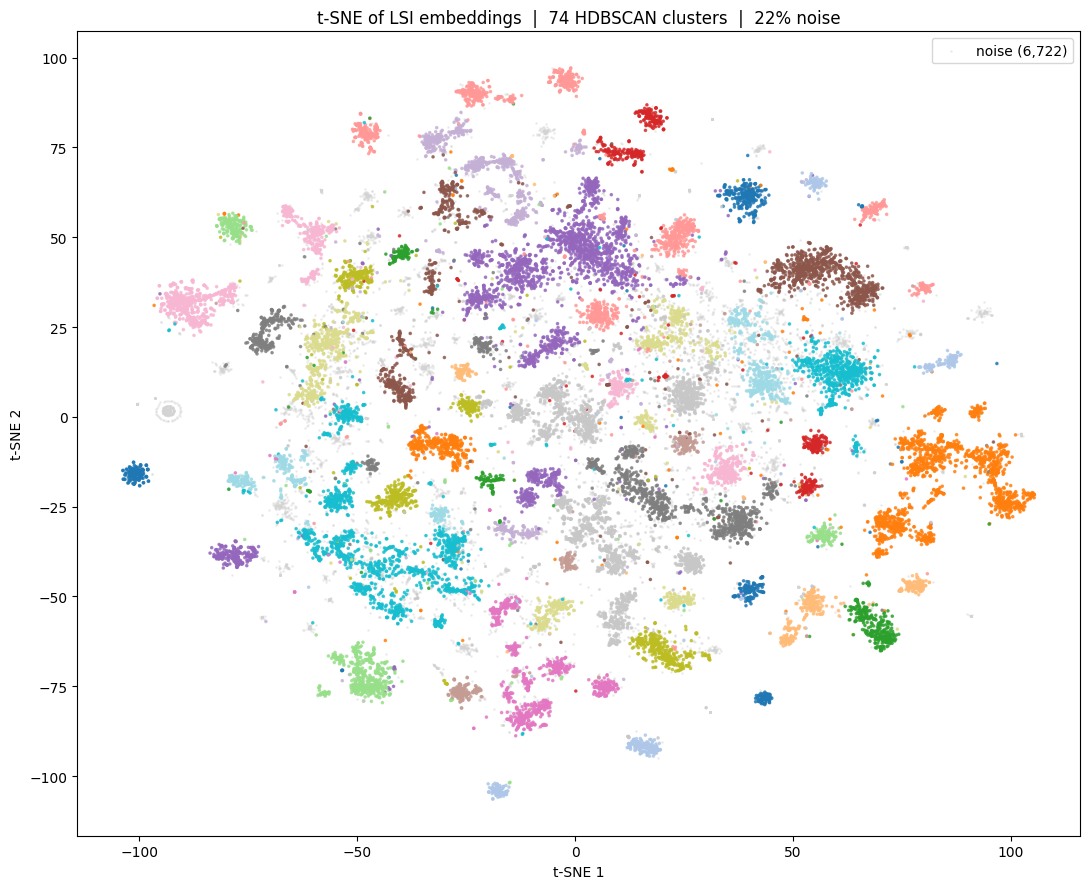

Saved → /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/tsne_clusters.png


In [27]:
n = min(tsne_max_points, len(X))
idx = RNG.choice(len(X), size = n, replace=False)
Xv, lv = X[idx], labels[idx]

t0 = time.time()
tsne= TSNE(n_components = 2, perplexity=50, metric='cosine', n_jobs=-1, random_state=42,
           n_iter=750, verbose=False)
Z = tsne.fit(Xv)
print (f"t-SNE on {n:,} points in {time.time()-t0:.1f}s")

plt.figure(figsize=(11,9))
noise = lv == -1
plt.scatter(Z[noise, 0], Z[noise, 1], s=1, c='lightgrey', alpha=0.3, label=f'noise ({noise.sum():,})')
sc = plt.scatter(Z[~noise, 0], Z[~noise, 1], s=2.5, c=lv[~noise], cmap='tab20', alpha=0.75)
plt.title(f't-SNE of LSI embeddings  |  {n_clusters} HDBSCAN clusters  |  {noise_frac:.0%} noise')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend(loc='upper right')
plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'tsne_clusters.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', plot_path)

Export per article cluster assignments

In [28]:
keep_cols = [c for c in [pub_col, date_col, 'year', 'title', 'url', 'summary']
             if c in sample.columns]
out = sample[keep_cols + ['cluster', 'cluster_prob']].copy()
out_path = os.path.join(OUT_DIR, 'cluster_assignments.csv')
out.to_csv(out_path, index=False)
print('Saved →', out_path, f'({len(out):,} rows)')
out.head()

Saved → /content/drive/MyDrive/CSDS 312 Project - Shared/outputs/topic_modeling/cluster_assignments.csv (74,987 rows)


,publisher_clean,date,year,title,url,summary,cluster,cluster_prob
0,9news.com,2014091419,2014,Dark web gives criminals their own untraceable...,http://www.9news.com.au/national/2014/09/14/22...,"Drug deals, hacking services, even murders for...",58,1.000000
1,9news.com,20140720003823,2014,Sleeping infant babysat by serpents,http://www.9news.com.au/world/2013/10/28/10/52...,This baby in India has some very unusual soft ...,-1,0.000000
2,9news.com,2014122819,2014,Missing AirAsia crew member tweeted about MH17...,http://www.9news.com.au/world/2014/12/29/05/05...,A flight attendant aboard a missing AirAsia pl...,10,0.512661
3,9news.com,20140731203030,2014,EU widens sanctions against Russia,http://www.9news.com.au/world/2014/07/30/01/40...,The European Union has agreed to impose broad ...,20,0.860245
4,9news.com,2014083019,2014,First block of gold worth $18k buried by artis...,http://www.9news.com.au/world/2014/08/31/02/01...,The first block of gold buried by an artist on...,-1,0.000000


Check

In [29]:
# Top 10 clusters by size × publisher distribution (proportions)
top10 = top_terms_df.query('not is_noise').head(10)['cluster'].tolist()
pub_mat = (out[out['cluster'].isin(top10)]
           .groupby(['cluster', pub_col]).size()
           .unstack(fill_value=0))
pub_prop = pub_mat.div(pub_mat.sum(axis=1), axis=0).round(3)
print('Publisher distribution within top-10 clusters (row-normalized):')
pub_prop

Publisher distribution within top-10 clusters (row-normalized):


publisher_clean,9news.com,abcnews,aol,bbc,bloomberg,bostonglobe,cbc,cnbc,cnn,forbes,...,reuters,sfgate,telegraph,theguardian,thesun,time,tmz,usatoday,washingtonpost,wsj
cluster,,,,,,,,,,,,,,,,,,,,,
8,0.002,0.004,0.010,0.000,0.001,0.004,0.009,0.004,0.025,0.012,...,0.001,0.056,0.001,0.036,0.002,0.017,0.021,0.115,0.111,0.032
29,0.016,0.007,0.015,0.006,0.001,0.011,0.010,0.009,0.057,0.023,...,0.002,0.010,0.011,0.042,0.008,0.045,0.004,0.027,0.123,0.042
30,0.106,0.010,0.012,0.005,0.001,0.005,0.025,0.002,0.056,0.005,...,0.001,0.017,0.009,0.062,0.024,0.032,0.017,0.018,0.079,0.025
40,0.003,0.007,0.006,0.005,0.000,0.090,0.008,0.003,0.023,0.004,...,0.001,0.008,0.022,0.068,0.012,0.037,0.024,0.031,0.044,0.032
49,0.031,0.011,0.046,0.007,0.034,0.013,0.005,0.004,0.044,0.004,...,0.009,0.004,0.003,0.085,0.009,0.068,0.010,0.006,0.191,0.056
53,0.007,0.004,0.020,0.007,0.005,0.068,0.008,0.018,0.016,0.027,...,0.002,0.081,0.022,0.054,0.004,0.020,0.011,0.012,0.072,0.075
56,0.031,0.007,0.014,0.064,0.003,0.009,0.022,0.007,0.050,0.017,...,0.003,0.022,0.054,0.056,0.018,0.033,0.008,0.062,0.050,0.036
58,0.010,0.013,0.016,0.011,0.003,0.041,0.016,0.017,0.065,0.033,...,0.004,0.007,0.017,0.037,0.019,0.081,0.005,0.042,0.067,0.045
68,0.003,0.004,0.011,0.013,0.019,0.040,0.005,0.111,0.019,0.170,...,0.014,0.012,0.017,0.011,0.004,0.028,0.001,0.034,0.040,0.138


/tmp/ipykernel_84903/792224598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y= cluster_counts.values, palette="viridis")


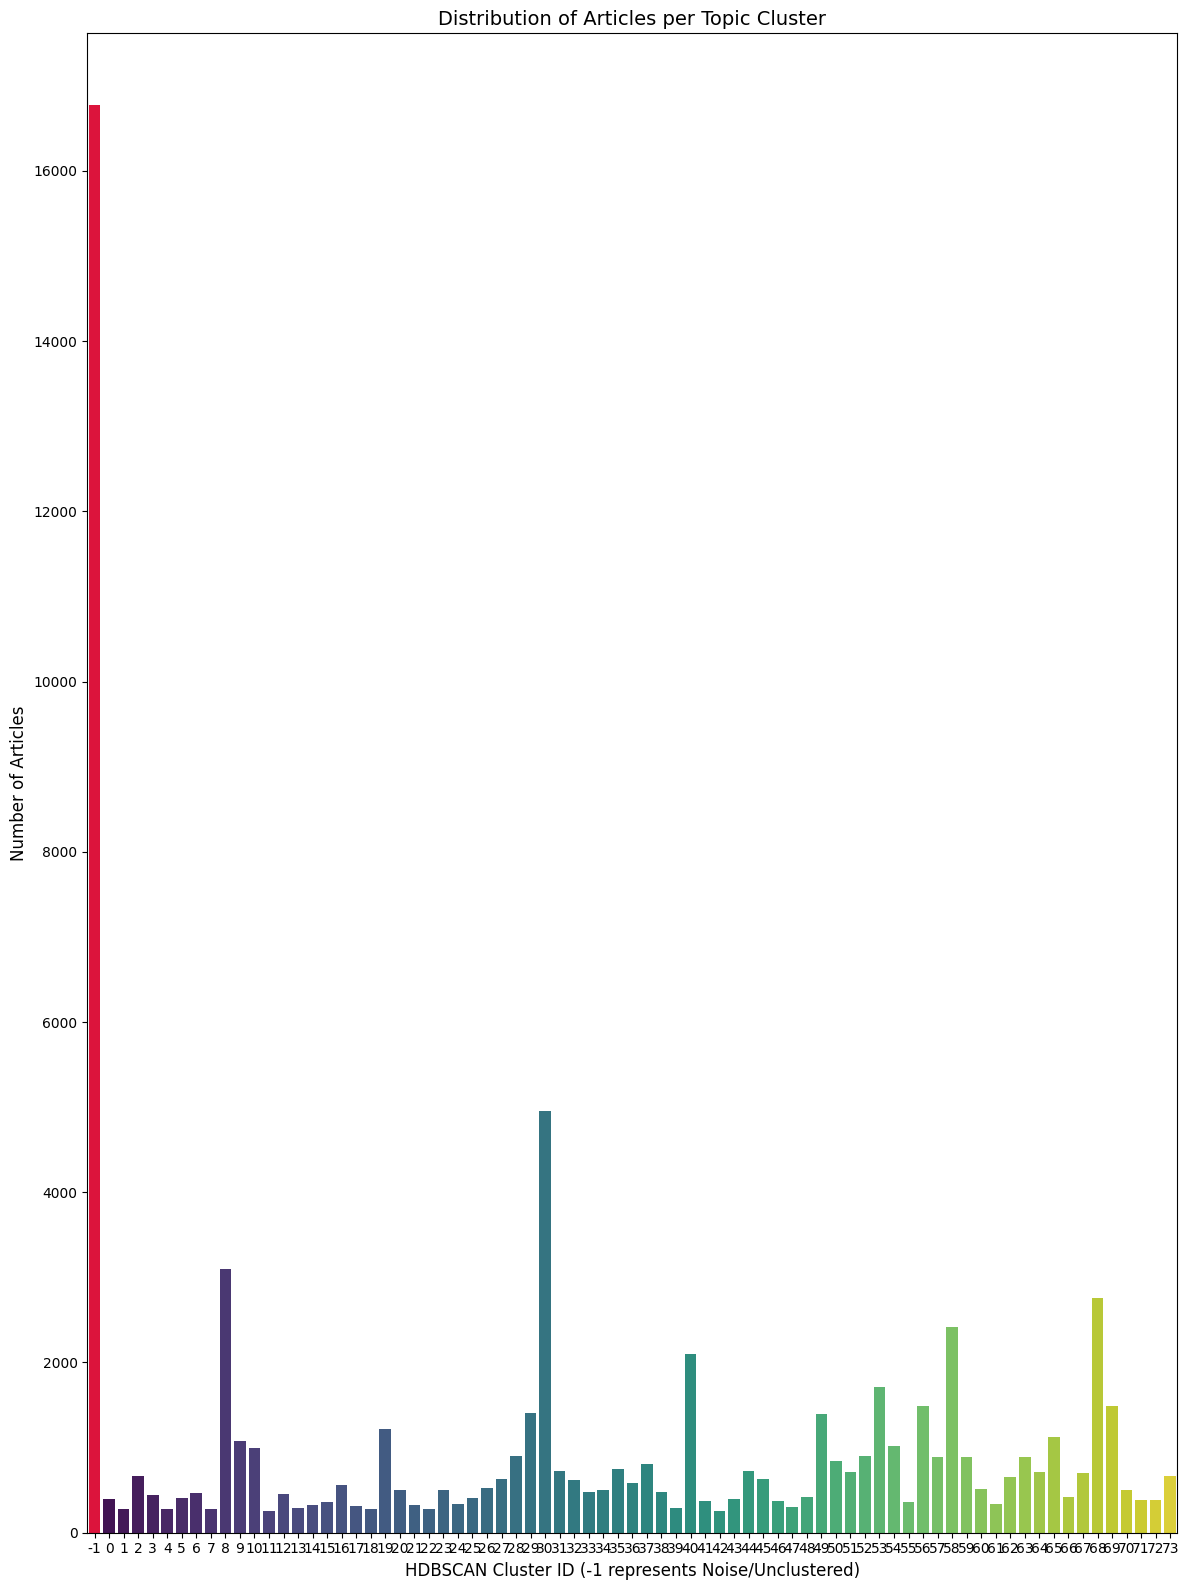

In [30]:
#HDSCAN visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Create a series from the labels
cluster_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(12,16))
#Use bar plot
sns.barplot(x=cluster_counts.index, y= cluster_counts.values, palette="viridis")

plt.title("Distribution of Articles per Topic Cluster", fontsize=14)
plt.xlabel("HDBSCAN Cluster ID (-1 represents Noise/Unclustered)", fontsize=12)
plt.ylabel("Number of Articles", fontsize = 12)

#Highlight the noise cluster in red for transparency
if -1 in cluster_counts.index:
  plt.gca().patches[0].set_facecolor('crimson')

plt.tight_layout()
plt.show()

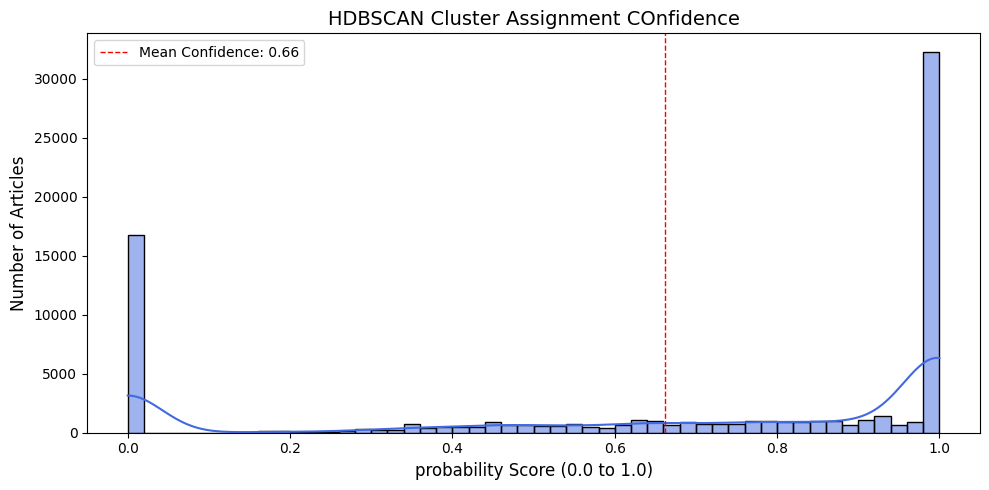

In [31]:
#histogram to display HDBSCAN probabilities
plt.figure(figsize=(10, 5))

sns.histplot(probs, bins=50, kde=True, color='royalblue')

plt.title("HDBSCAN Cluster Assignment COnfidence", fontsize=14)
plt.xlabel("probability Score (0.0 to 1.0)", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

plt.axvline(x=probs.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean Confidence: {probs.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

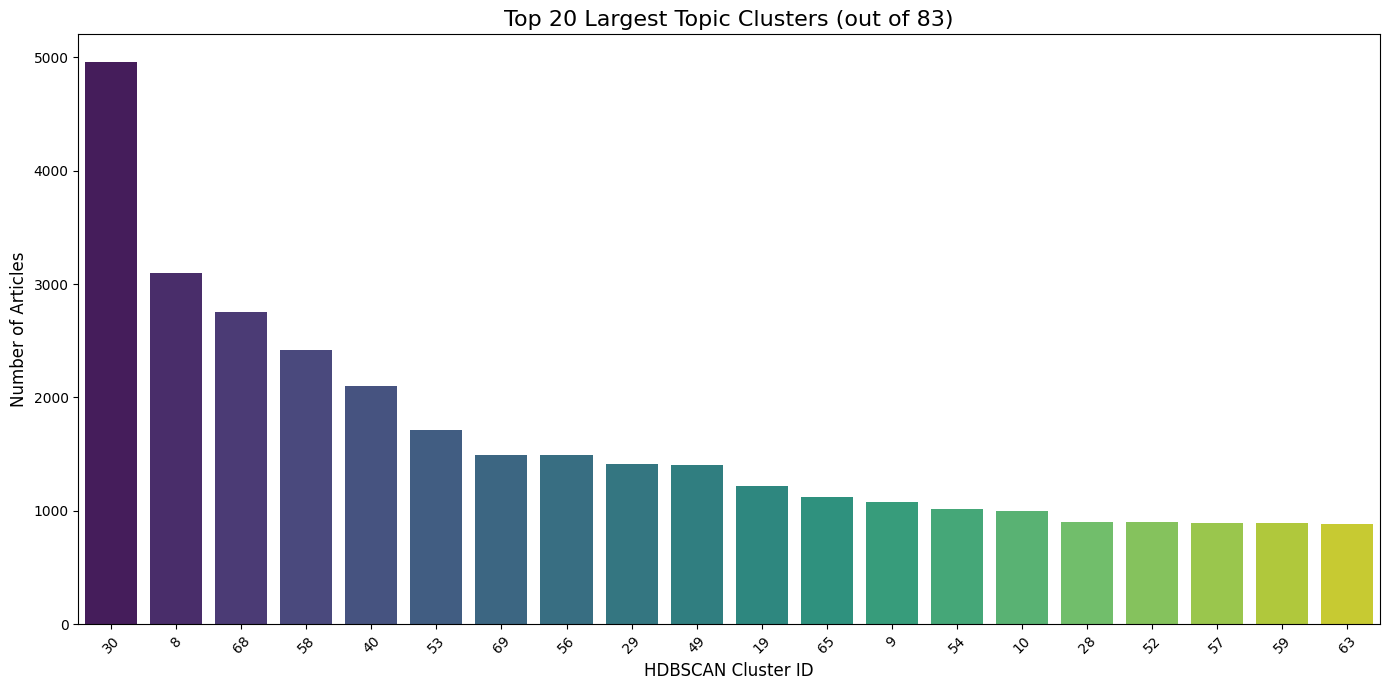

In [32]:
#Plotting top 20 clusters
#seperate noise
valid_clusters = cluster_counts[cluster_counts.index != -1]

sorted_clusters = valid_clusters.sort_values(ascending=False)

#select top 20 valid clusters
top_n = 20
top_clusters = sorted_clusters.head(top_n).copy()

#Plot
plt.figure(figsize=(14,7))
sns.barplot(x=top_clusters.index.astype(str),
            y=top_clusters.values,
            order=top_clusters.index.astype(str),
            hue=top_clusters.index.astype(str),
            palette="viridis", legend=False)

plt.title(f"Top {top_n} Largest Topic Clusters (out of 83)", fontsize=16)
plt.xlabel("HDBSCAN Cluster ID", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_84903/1643582879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cluster_counts.index.astype(str), x=cluster_counts.values, orient='h', palette="viridis")


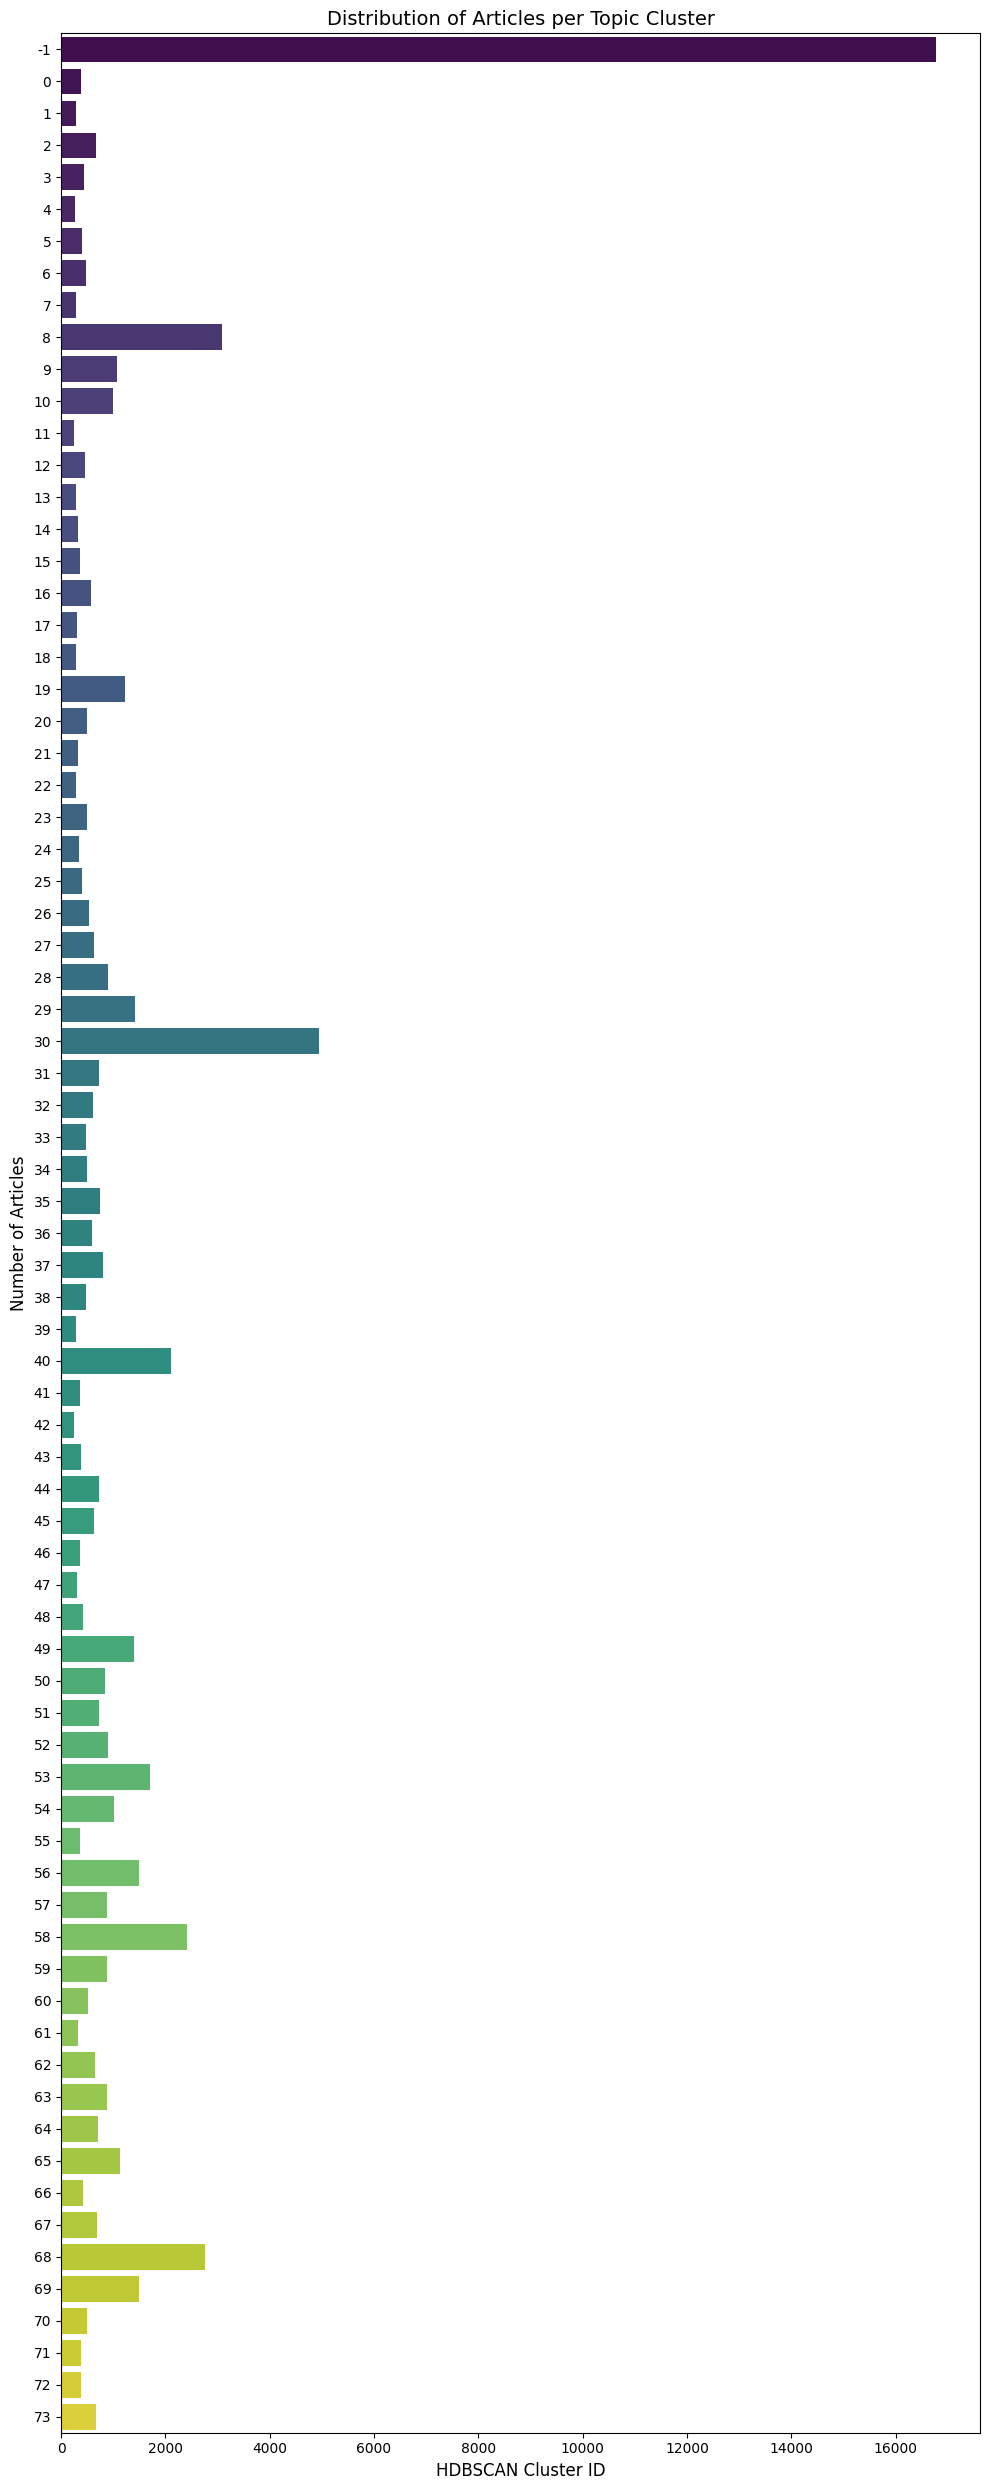

In [33]:
#Horizontal bar chart for all clusters
plt.figure(figsize=(10,25))

#set orient and swapping x and y
sns.barplot(y=cluster_counts.index.astype(str), x=cluster_counts.values, orient='h', palette="viridis")

plt.title("Distribution of Articles per Topic Cluster", fontsize=14)
plt.xlabel("HDBSCAN Cluster ID", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
/tmp/ipykernel_84903/2663204445.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=chunks[i].index.astype(str), x=chunks[i].values,
/tmp/ipykernel_84903/2663204445.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=chunks[i].index.astype(str), x=chunks[i].values,
/tmp/ipykernel_84903/2663204445.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False

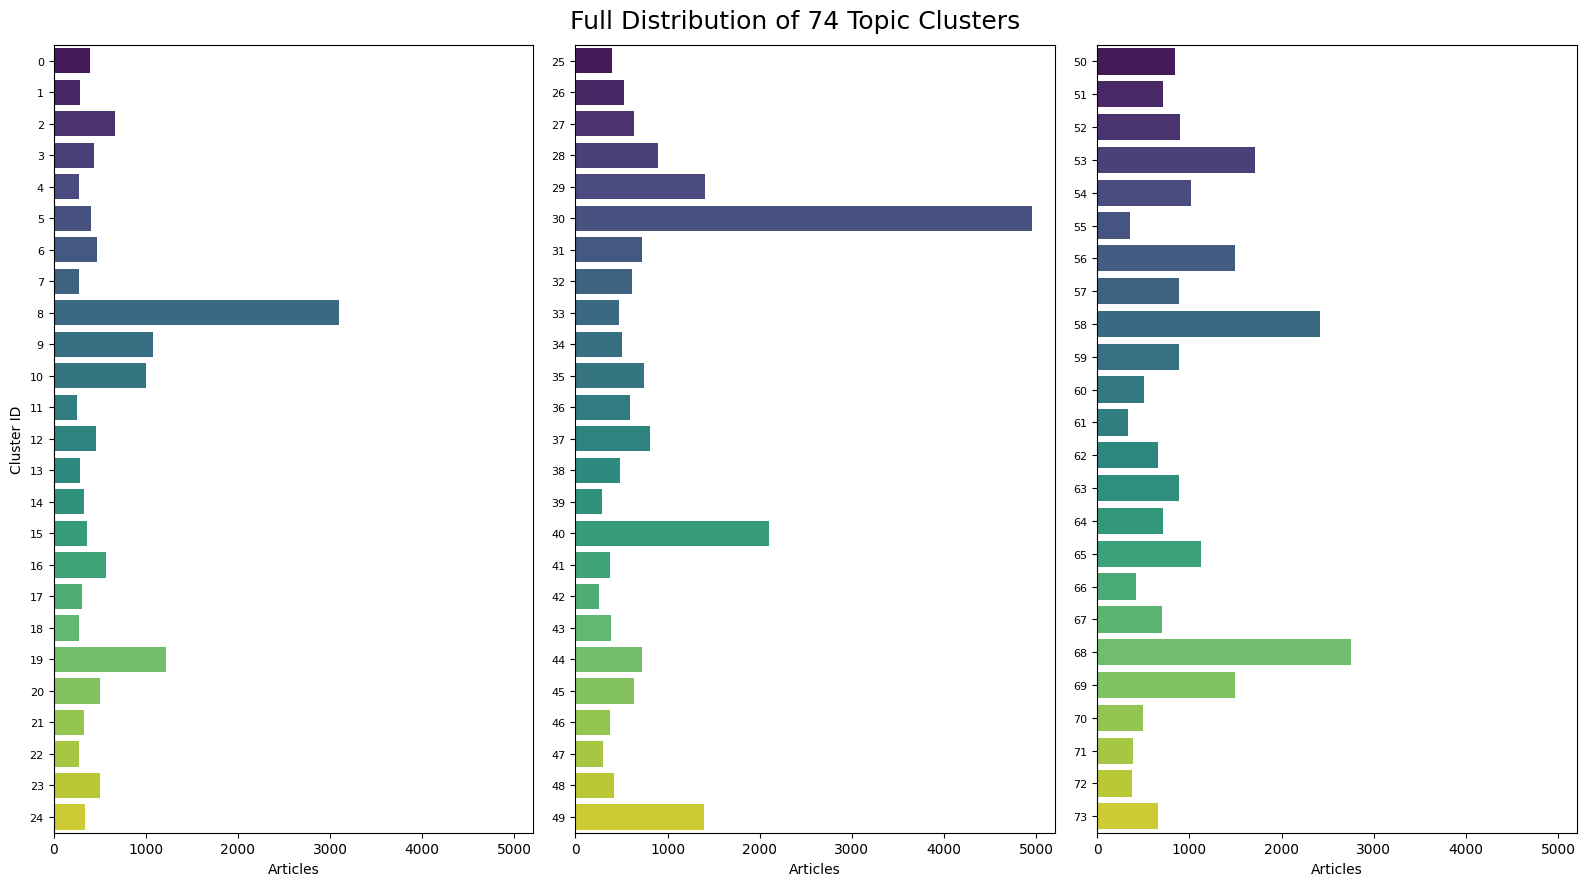

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

valid_clusters = cluster_counts[cluster_counts.index != -1]

# Set up a 16x9 figure with 3 columns
fig, axes = plt.subplots(1, 3, figsize=(16, 9), sharex=True)

# Split the data into 3 roughly equal chunks
chunks = np.array_split(valid_clusters, 3)

for i, ax in enumerate(axes):
    sns.barplot(y=chunks[i].index.astype(str), x=chunks[i].values,
                palette="viridis", orient='h', ax=ax)

    ax.set_xlabel("Articles")
    ax.set_ylabel("Cluster ID" if i == 0 else "")
    # Shrink the font size so it fits
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Full Distribution of 74 Topic Clusters", fontsize=18)
plt.tight_layout()
plt.show()

In [36]:
# After loading initial dataset
# Rename the existing 'cluster' column to 'topic_cluster' in the sample DataFrame
sample = sample.rename(columns={'cluster': 'topic_cluster'})

# Drop noise to avoid the skewing of analysis from the sample DataFrame
df_clean = sample[sample['topic_cluster'] != -1]

print(f"Data successfully merged! Clean articles remaining: {len(df_clean)}")

Data successfully merged! Clean articles remaining: 58210


In [46]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
analyzer = SentimentIntensityAnalyzer()

#Filter cleaned dataframe for political events
political_clusters = [30, 49, 52, 65]
df_politics = df_clean[df_clean['topic_cluster'].isin(political_clusters)].copy()

#define the scoring function
def get_inflammatory_score(text):
  return analyzer.polarity_scores(str(text))['neg']

#run sentiment analyser on the text
print("Running VADER sentiment analysis on political articles...")
df_politics['inflammatory_score'] = df_politics['text'].apply(get_inflammatory_score)
print("Done! Ready for plotting.")

Running VADER sentiment analysis on political articles...
Done! Ready for plotting.


In [47]:
df_politics.head()


,title,summary,text,url,domain,publisher_clean,date,datetime,year,month,day,year_month_day,title_len,summary_len,text_len,topic_cluster,cluster_prob,inflammatory_score
5,Greg Anderson ‘100 per cent bad’: Luke Batty inquest,"Luke Batty&rsquo;s father was &ldquo;100 per cent bad&rdquo;, a police offic...","Luke Batty’s father was “100 per cent bad”, a police officer said today duri...",http://www.9news.com.au/national/2014/10/23/18/16/greg-anderson-100-per-cent...,9news.com.au,9news.com,2014102319,2014-10-23 19:00:00,2014,10,23,2014-10-23,52,143,1390,30,1.000000,0.232
6,Search for elderly Sydney woman Gaida Coote enters fourth day,The search for an elderly woman missing in Sydney bushland for three days is...,"Gaida Coote, 84, vanished after visiting the Ku-Ring-Gai Wildflower Gardens ...",http://www.9news.com.au/national/2014/12/07/03/34/search-for-elderly-sydney-...,9news.com.au,9news.com,2014120619,2014-12-06 19:00:00,2014,12,6,2014-12-06,61,108,696,30,0.966889,0.049
8,"My husband is a survivor not a suspect, says convenience store blaze wife",Traces of accelerant have been found at the scene of a fire which levelled a...,The wife of the convenience store owner rescued from a deadly Sydney blaze s...,http://www.9news.com.au/national/2014/09/08/16/51/accelerant-found-at-rozell...,9news.com.au,9news.com,2014090819,2014-09-08 19:00:00,2014,9,8,2014-09-08,73,134,2411,30,1.000000,0.106
14,Young man plunges to his death from Melbourne apartment balcony,A man in his 20s has died after falling from a 26th floor balcony of a Melbo...,A party at an inner-Melbourne apartment building has come to a tragic ending...,http://www.9news.com.au/national/2014/12/06/10/28/vic-man-dies-after-26-floo...,9news.com.au,9news.com,2014120519,2014-12-05 19:00:00,2014,12,5,2014-12-05,63,97,1186,30,1.000000,0.239
17,'I have a gun. Now get in my van': Gable Tostee's chilling message to A Curr...,A Current Affair producer Stephanie Angus has spoken about her online encoun...,"August 12, 2014: There are few secrets about the last person to see Warriena...",http://www.9news.com.au/national/2014/08/12/19/57/a-current-affair-producer-...,9news.com.au,9news.com,2014081319,2014-08-13 19:00:00,2014,8,13,2014-08-13,95,163,2173,30,1.000000,0.078


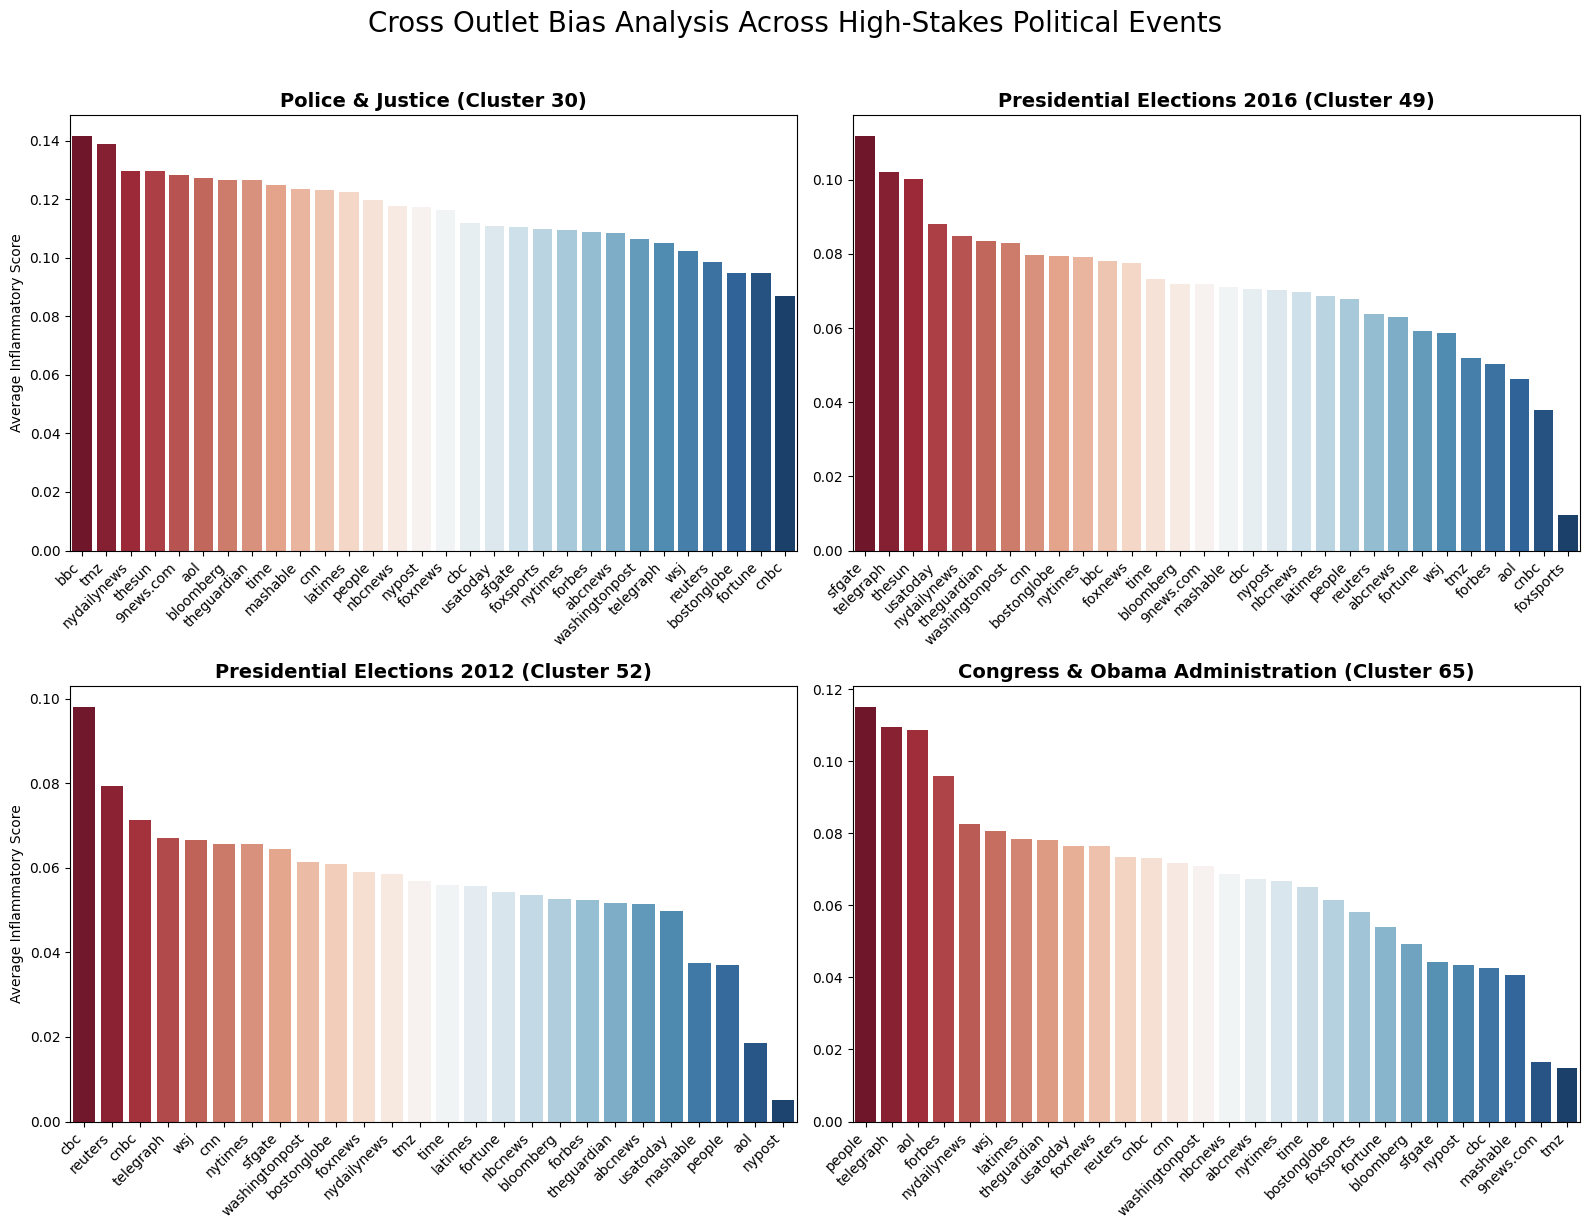

In [48]:
outlet_comparison = df_politics.groupby(['topic_cluster', 'publisher_clean'])['inflammatory_score'].mean().reset_index()

#Create dictionary to initialize idenitifiable clusters
cluster_names = {
    30: "Police & Justice (Cluster 30)",
    49: "Presidential Elections 2016 (Cluster 49)",
    52: "Presidential Elections 2012 (Cluster 52)",
    65: "Congress & Obama Administration (Cluster 65)"
}

#2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

#loop for each cluster, plot
for i, cluster_id in enumerate(cluster_names.keys()):

  #filter to only this cluster before sorting/plotting
  cluster_data = (outlet_comparison[outlet_comparison["topic_cluster"] == cluster_id]
                  .sort_values(by="inflammatory_score", ascending=False))
  #plot bar chart
  sns.barplot(data=cluster_data, x="publisher_clean", y="inflammatory_score",
              hue="publisher_clean", palette="RdBu", ax=axes[i], legend=False)

  #format subplot
  axes[i].set_title(cluster_names[cluster_id], fontsize = 14, fontweight='bold')
  axes[i].set_xlabel("")
  axes[i].set_ylabel("Average Inflammatory Score" if i % 2 == 0 else "")

  for tick in axes[i].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha('right')

plt.suptitle("Cross Outlet Bias Analysis Across High-Stakes Political Events", fontsize=20, y=1.02)

plt.tight_layout()
plt.show()

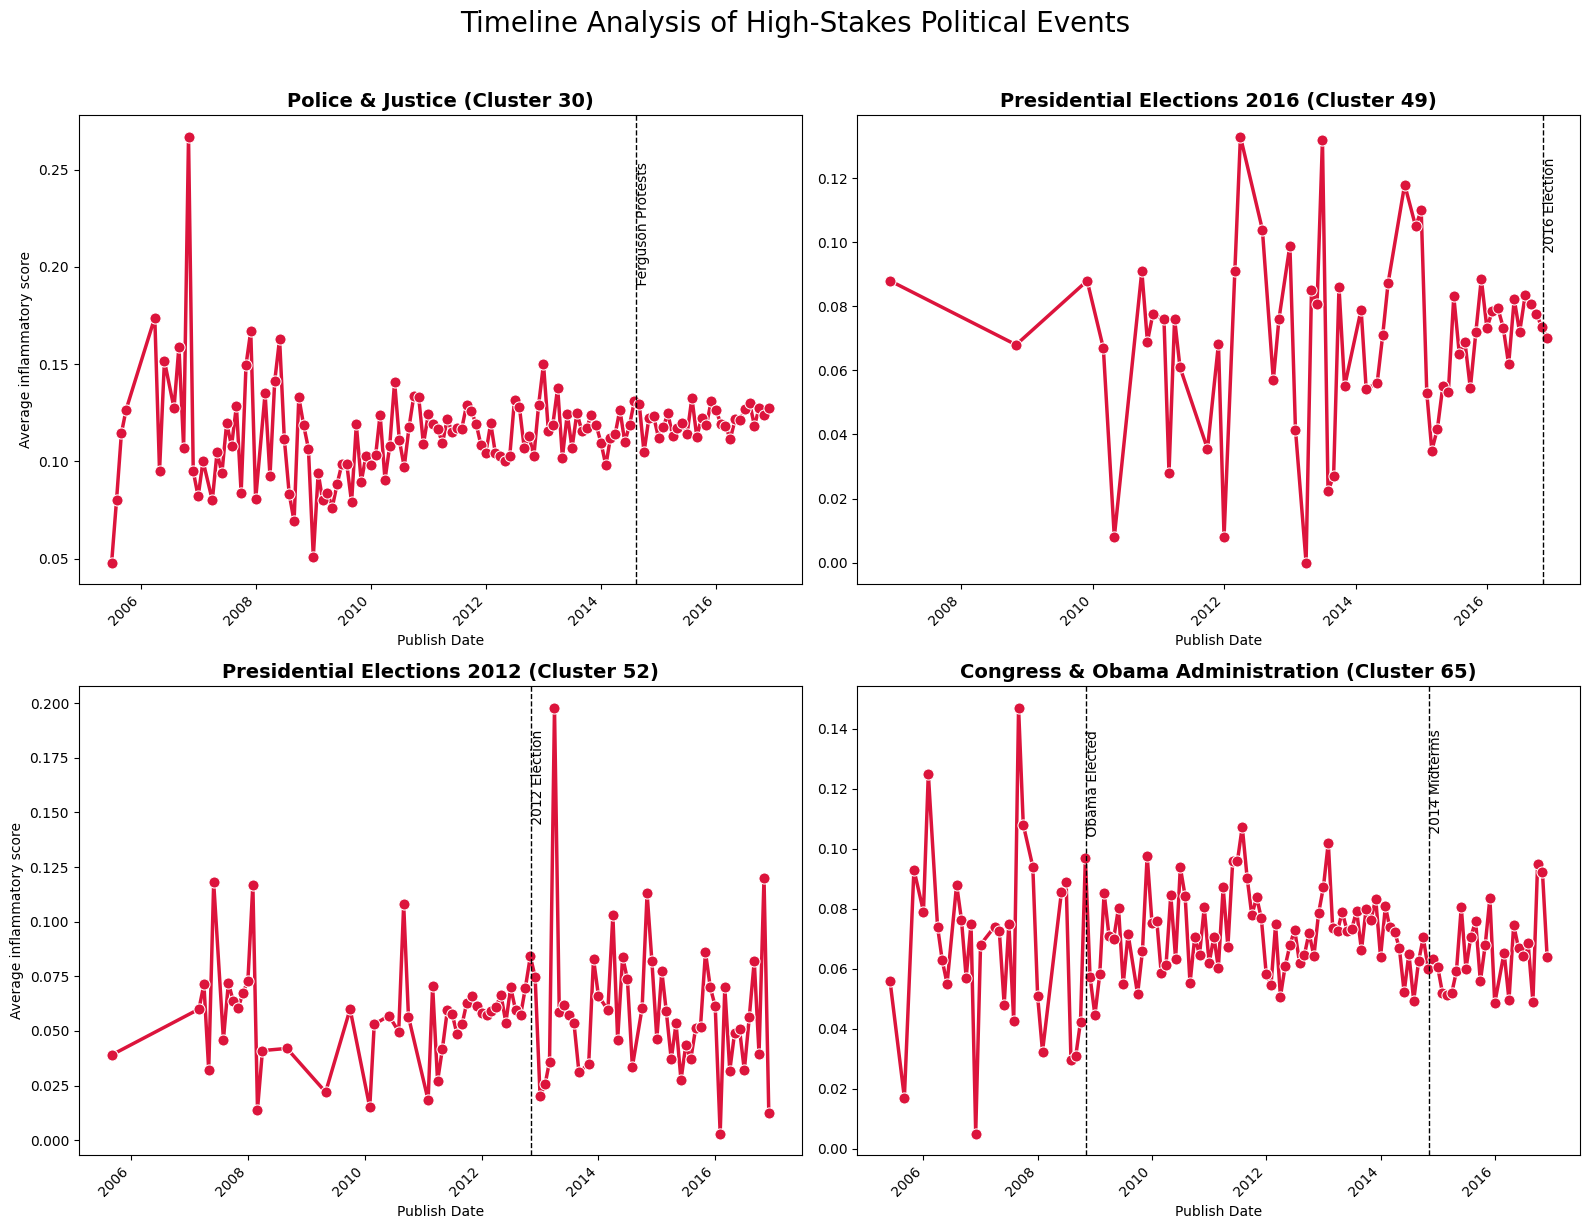

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#time series analysis of sentiment

#preparing dates
df_politics['datetime'] = pd.to_datetime(df_politics['datetime'])

#setting cluster column to integers
df_politics['topic_cluster'] = pd.to_numeric(df_politics['topic_cluster'], errors='coerce').fillna(-1).astype(int)

#extracting the Year and Month
df_politics['year_month'] = df_politics['datetime'].dt.to_period('M')

#grouping data by cluster and month to retrieve timeline averages
time_data = df_politics.groupby(['topic_cluster', 'year_month'])['inflammatory_score'].mean().reset_index()
time_data['year_month'] = time_data['year_month'].dt.to_timestamp()

#defining specific events in each cluster
cluster_configs = {
    30: {
        "title": "Police & Justice (Cluster 30)",
        "events": [("2014-08-09", "Ferguson Protests")]
    },
    49: {
        "title": "Presidential Elections 2016 (Cluster 49)",
        "events": [("2016-11-08", "2016 Election")]
    },
    52: {
        "title": "Presidential Elections 2012 (Cluster 52)",
        "events": [("2012-11-06", "2012 Election")]
    },
    65: {
        "title": "Congress & Obama Administration (Cluster 65)",
        "events": [("2008-11-04", "Obama Elected"),
                   ("2014-11-04", "2014 Midterms")]
    }
}

# 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

# Ensure clusters are integers so they match your dictionary perfectly
time_data['topic_cluster'] = time_data['topic_cluster'].astype(int)

for i, (cluster_id, config) in enumerate(cluster_configs.items()):
  # filter for singular cluster
  cluster_timeline = time_data[time_data['topic_cluster'] == cluster_id]

  # line chart - ADDED marker='o' and markersize
  sns.lineplot(data=cluster_timeline, x='year_month', y='inflammatory_score',
               color='crimson', linewidth=2.5, marker='o', markersize=8, ax=axes[i])

  # vertical event lines
  for date_str, event_name in config["events"]:
    event_date = pd.to_datetime(date_str)

    if not cluster_timeline.empty and event_date >= cluster_timeline['year_month'].min() and event_date <= cluster_timeline['year_month'].max():
      axes[i].axvline(x=event_date, color='black', linestyle='--', linewidth=1)
      # text describing line
      axes[i].text(event_date, cluster_timeline['inflammatory_score'].max() * 0.95,
                   f' {event_name}', rotation=90, verticalalignment='top')

  # formatting
  axes[i].set_title(config['title'], fontsize=14, fontweight='bold')
  axes[i].set_xlabel("Publish Date")
  axes[i].set_ylabel("Average inflammatory score" if i % 2 == 0 else "")

  for tick in axes[i].get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha('right')

plt.suptitle("Timeline Analysis of High-Stakes Political Events", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("vader_4cluster_timeline.png", dpi=300, bbox_inches='tight')
plt.show()

In [51]:
print("--- DATASET TIMELINE CHECK ---")
print(f"Oldest article: {df_politics['datetime'].min()}")
print(f"Newest article: {df_politics['datetime'].max()}\n")

print("--- CLUSTER DATA CHECK ---")
for cluster in [30, 49, 52, 65]:
    count = len(df_politics[df_politics['topic_cluster'] == cluster])
    print(f"Cluster {cluster} has {count} total articles.")

--- DATASET TIMELINE CHECK ---
Oldest article: 2005-06-23 19:00:00
Newest article: 2016-12-31 19:34:05

--- CLUSTER DATA CHECK ---
Cluster 30 has 4954 total articles.
Cluster 49 has 1400 total articles.
Cluster 52 has 900 total articles.
Cluster 65 has 1124 total articles.
